In [ ]:
import os
import sys
from datetime import datetime
from rfdetr import RFDETRMedium

sys.path.insert(0, os.path.join(os.getcwd(), '..', '..'))

from config import WORK_DIR, PSEUDO_DATASET_DIR, IPHONE_DATASET_DIR, RFDETR_OUTPUT_DIR

model = RFDETRMedium()
dataset_dir = PSEUDO_DATASET_DIR
OUTPUT_PATH = RFDETR_OUTPUT_DIR

run_output = OUTPUT_PATH + '/' + datetime.now().strftime("%d%m_%H%M%S")
model.train(
    dataset_dir=dataset_dir,
    epochs=50,
    batch_size=4,
    grad_accum_steps=4,
    lr=1e-4,
    output_dir=run_output,
    tensorboard=True,
    imgsz = 1280
)

In [1]:
import os
from datetime import datetime
from rfdetr import RFDETRMedium
import supervision as sv


In [ ]:
model = RFDETRMedium()
dataset_dir = PSEUDO_DATASET_DIR
OUTPUT_PATH = RFDETR_OUTPUT_DIR

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


In [ ]:
run_output = OUTPUT_PATH + '/' + datetime.now().strftime("%d%m_%H%M%S")
model.train(
    dataset_dir=dataset_dir,
    epochs=50,
    batch_size=4,
    grad_accum_steps=4,
    lr=1e-4,
    output_dir=run_output,
    tensorboard=True,
    imgsz = 1024
)

In [20]:
result

Detections(xyxy=array([[1373.5848 ,  581.29407, 1383.3379 ,  718.8623 ],
       [ 612.9855 ,  604.00604,  621.4827 ,  729.97644]], dtype=float32), mask=None, confidence=array([0.68587404, 0.45749518], dtype=float32), class_id=array([0, 0]), tracker_id=None, data={}, metadata={})

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


0 hits


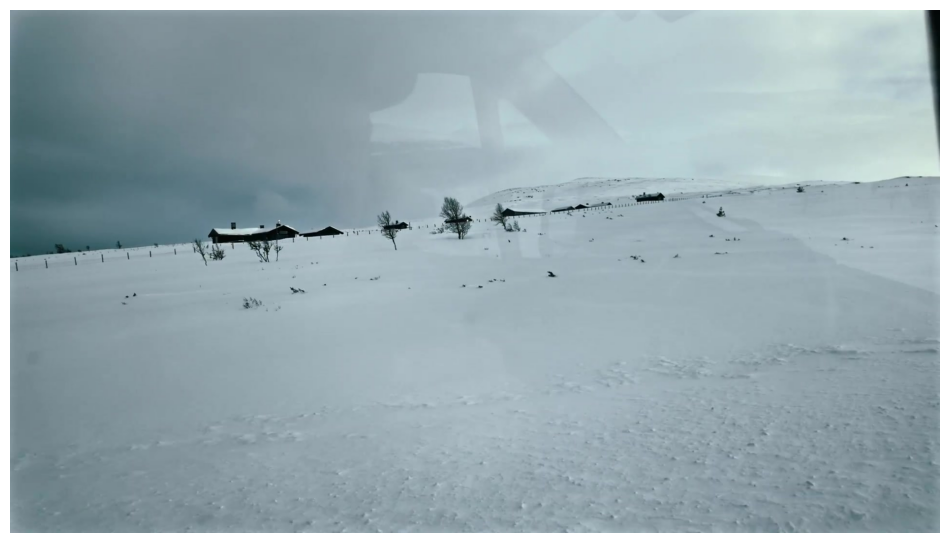

0 hits


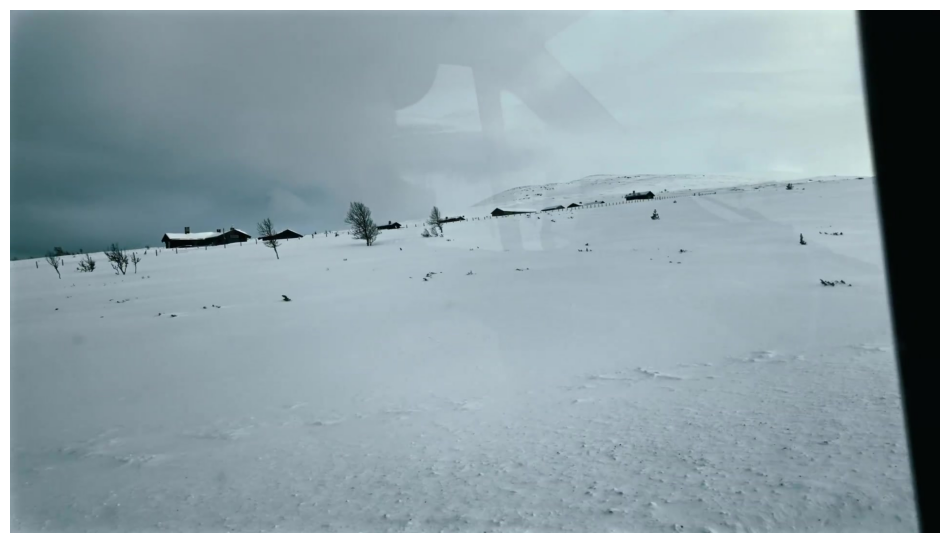

0 hits


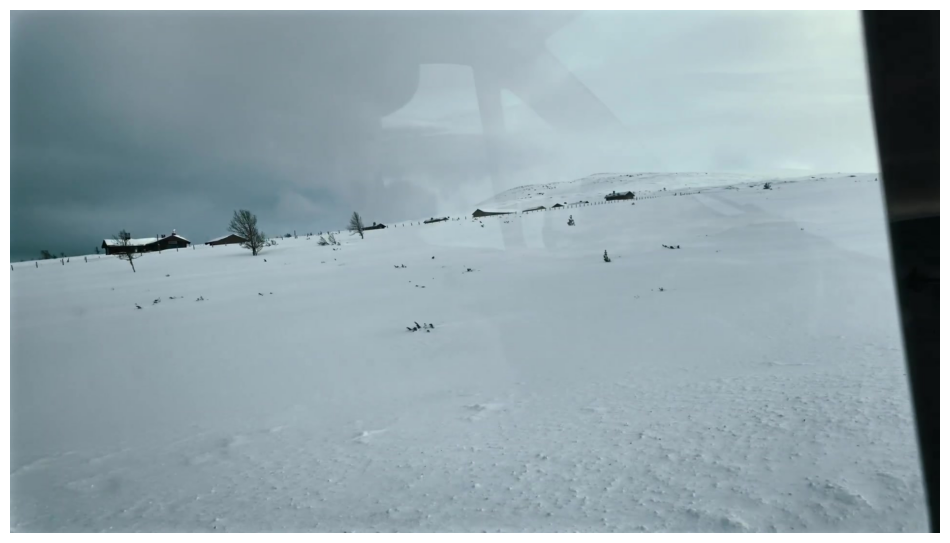

2 hits


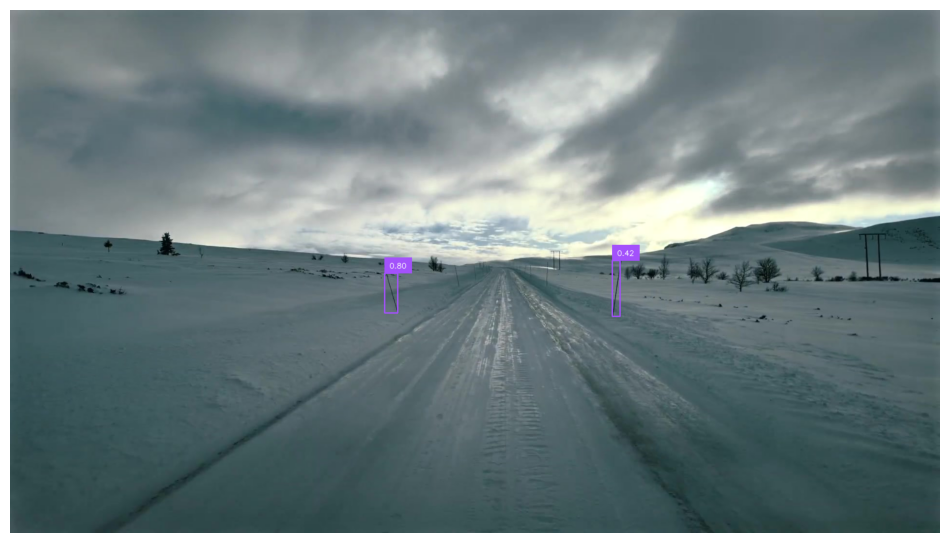

2 hits


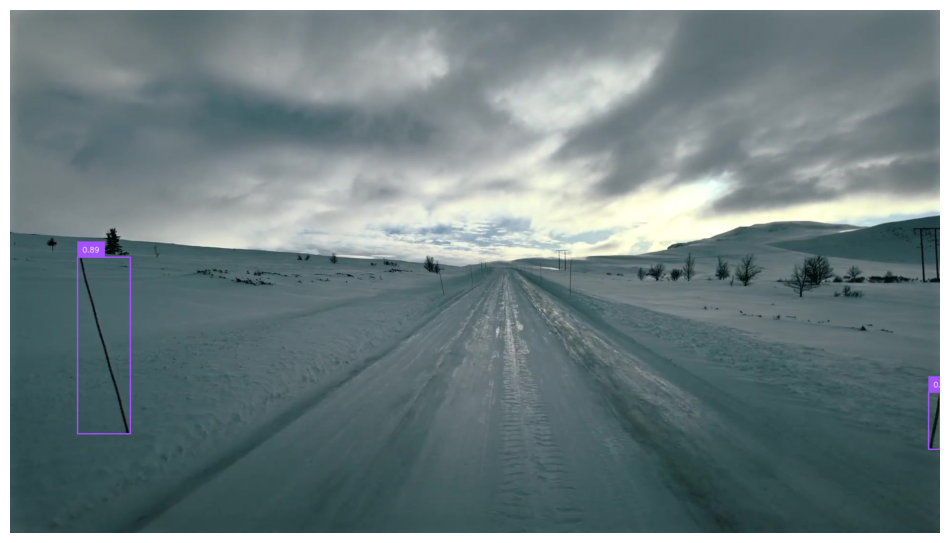

1 hits


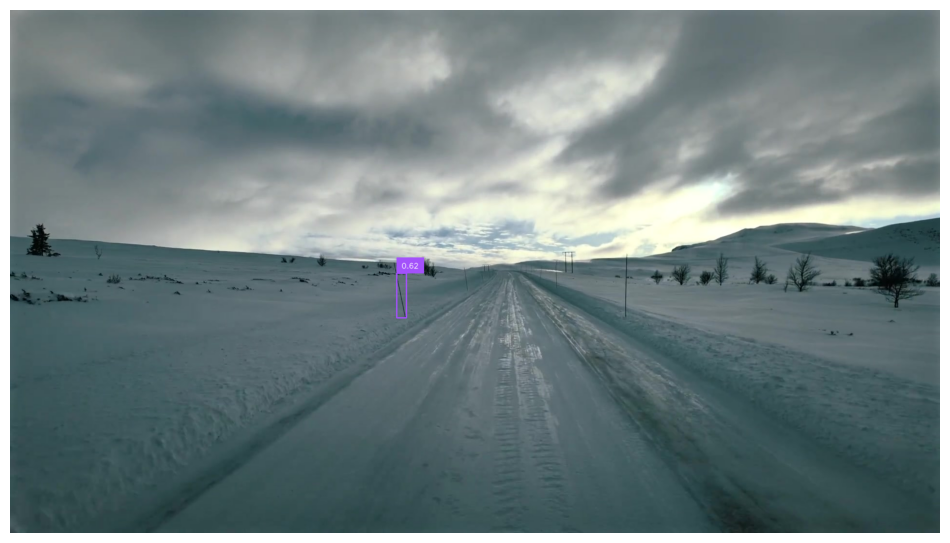

In [ ]:
import supervision as sv

# 1. Run Prediction
# Note: Use 'threshold', not 'confidence' for the local package
CHECKPOINT_PATH = os.path.join(RFDETR_OUTPUT_DIR, 'YOUR_RUN_FOLDER', 'checkpoint_best_ema.pth')
model = RFDETRMedium(pretrain_weights=CHECKPOINT_PATH)






images = [os.path.join(YT_DATASET_DIR, f'frame_{i:05d}.jpg') for i in range(554, 560)]
images = [Image.open(path) for path in images]


for image in images:
    detections = model.predict(image, threshold=0.2)
    print(len(detections), 'hits')
    
    labels = [f"{confidence:.2f}" for confidence in detections.confidence]
    
    # 4. Annotate
    annotated_image = image.copy()
    annotated_image = sv.BoxAnnotator().annotate(annotated_image, detections)
    annotated_image = sv.LabelAnnotator().annotate(annotated_image, detections, labels=labels)
    
    # 5. Show
    sv.plot_image(annotated_image)